## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Ryan Fang

**Date:** 10/2/2026

In [1]:
# Your Phase 1 solution to the problem goes here.

1. Regression is used to predict a number, like how money something costs while classification is used to predict a group or type of thing.

2. A confusion table is a grid that counts predictions by putting the actual classes in rows and the predicted classes in columns. It puts the classes in the rows and the predicted classes in the columns. It helps understand how well the model is doing better than looking at simply accuracy. The diagonal cells show where the model was right and non-diagonal ones show which classes the model mixed up.

3. The Sum of Squared Error (SSE) measures how big the errors are in a models predictions. It adds up all the differences between the predicted values and the actual values. A lower SSE means the model's predictions were closer to the actual values for that dataset.

4. Overfitting happens when a model learns the mistakes in the training data instead of the real patterns. This often happens when k is really small. Underfitting happens when a model is too simple to see the differences between the data points. This happens when k is so big that the model gives the same prediction for everything.

5. Splitting the data helps check how well a model works on data that it has not seen before. If you choose k based on the training data/error it can lead to overfitting by picking a small k. Checking the SSE or accuracy on a separate test set gives a better idea of how the model will perform in real life.

6. Choosing one class label, such as the most common class label among the neighbors gives a clear definitive answer. But, calculating a probability for each class, such as dividing how many neighbors are in each class by k, shows how sure the model is. It shows if the prediction was a clear majority choice or a close guess.

In [2]:
# Q2 Part 1: Load and EDA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

df = pd.read_csv("land_mines.csv")

features = ['voltage', 'height', 'soil', 'mine_type']
for var in features:
    df[f'{var}_clean'] = pd.to_numeric(df[var], errors='coerce')
    df[f'{var}_nan'] = df[f'{var}_clean'].isnull()

# missing values
print("Missing values per column after coercion:")
print(df[[f'{var}_nan' for var in features]].sum())

# summary numeric features and target
print("\nSummary Statistics:")
print(df[[f'{var}_clean' for var in features]].describe().round(3))

Missing values per column after coercion:
voltage_nan      0
height_nan       0
soil_nan         0
mine_type_nan    0
dtype: int64

Summary Statistics:
       voltage_clean  height_clean  soil_clean  mine_type_clean
count        338.000       338.000     338.000          338.000
mean           0.431         0.509       0.504            2.953
std            0.196         0.306       0.344            1.420
min            0.198         0.000       0.000            1.000
25%            0.310         0.273       0.200            2.000
50%            0.360         0.545       0.600            3.000
75%            0.483         0.727       0.800            4.000
max            1.000         1.000       1.000            5.000


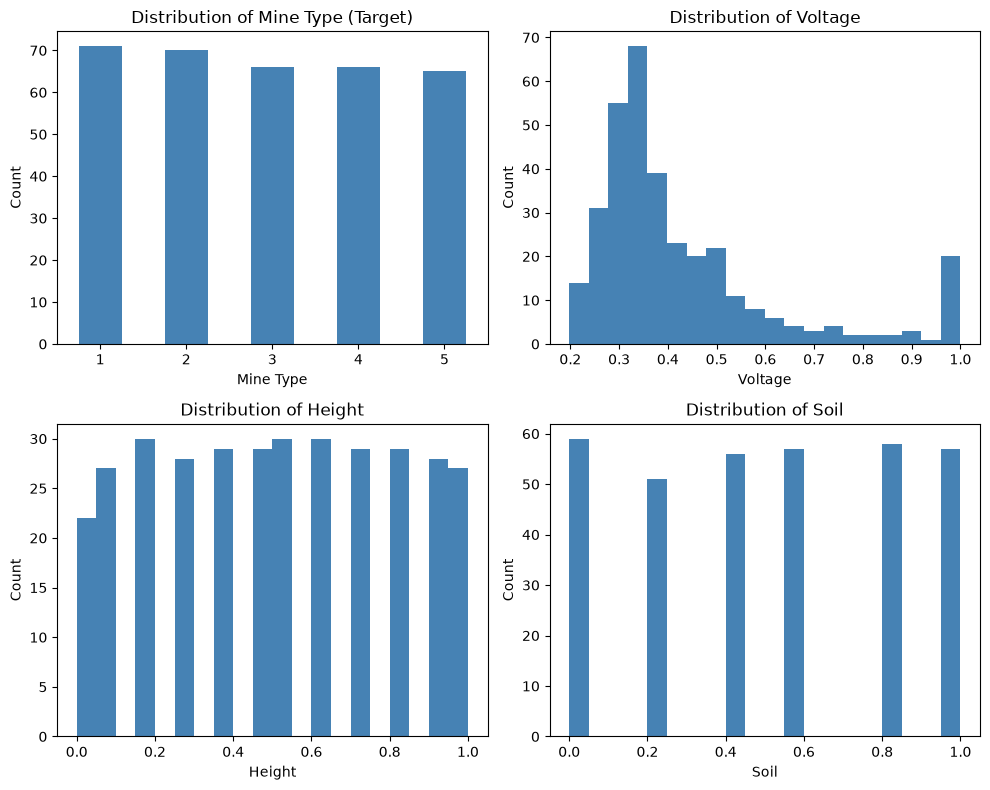

In [3]:
# EDA visualization 
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Target: mine_type
df['mine_type_clean'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title("Distribution of Mine Type (Target)")
axes[0, 0].set_xlabel("Mine Type")
axes[0, 0].set_ylabel("Count")
axes[0, 0].tick_params(axis='x', rotation=0)

# Feature: voltage
df['voltage_clean'].hist(bins=20, ax=axes[0, 1], grid=False, color='steelblue')
axes[0, 1].set_title("Distribution of Voltage")
axes[0, 1].set_xlabel("Voltage")
axes[0, 1].set_ylabel("Count")

# Feature: height
df['height_clean'].hist(bins=20, ax=axes[1, 0], grid=False, color='steelblue')
axes[1, 0].set_title("Distribution of Height")
axes[1, 0].set_xlabel("Height")
axes[1, 0].set_ylabel("Count")

# Feature: soil
df['soil_clean'].hist(bins=20, ax=axes[1, 1], grid=False, color='steelblue')
axes[1, 1].set_title("Distribution of Soil")
axes[1, 1].set_xlabel("Soil")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

**EDA Findings:**
* **Target Label (`mine_type`):** The target variable contains discrete integer classes (1 to 5). Visualizing the target shows how the data is distributed across the 5 distinct mine types. 
* **Features (`voltage`, `height`, `soil`):** The summary statistics and histograms show that all features are numeric and distributed roughly between 0 and 1. There are no major long-tail outliers.
* **Missingness:** We checked and verified that there were no more `_nan` columns.

In [4]:
# Q2 Part 2: Split the sample 50/50

df_model = df.dropna(subset=['voltage_clean', 'height_clean', 'soil_clean', 'mine_type_clean']).copy()

X = df_model[['voltage_clean', 'height_clean', 'soil_clean']]
y = df_model['mine_type_clean']

# splitting 50/50 into training and test/validation sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.50, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test/Validation set size:", X_test.shape)
print("\nClass distribution in Training set:\n", y_train.value_counts().sort_index())
print("\nClass distribution in Test set:\n", y_test.value_counts().sort_index())

Training set size: (169, 3)
Test/Validation set size: (169, 3)

Class distribution in Training set:
 mine_type_clean
1    35
2    35
3    33
4    33
5    33
Name: count, dtype: int64

Class distribution in Test set:
 mine_type_clean
1    36
2    35
3    33
4    33
5    32
Name: count, dtype: int64


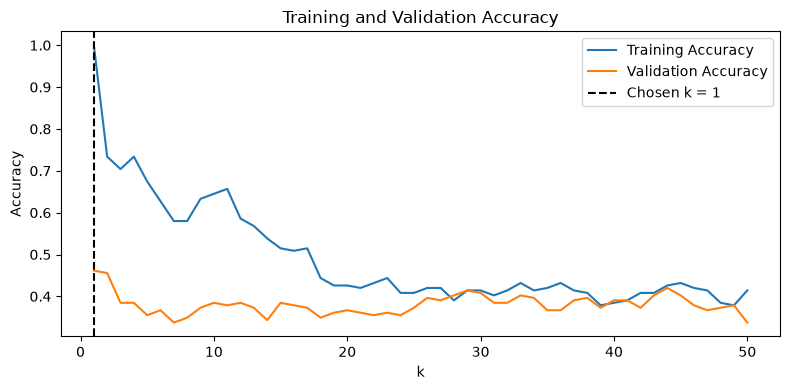

The optimal number of neighbors (k) is 1.


In [5]:
# Q2 Part 3: Build a k-NN classifier and select k
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import numpy as np

scaler = MinMaxScaler()

# fit_transform computes the training minima and maxima
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), 
    columns=X_train.columns, 
    index=X_train.index
)

# scale the validation features
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), 
    columns=X_test.columns, 
    index=X_test.index
)

eval_ks = np.arange(1, 51)
train_accuracy = []
test_accuracy = []

for k in eval_ks:
    candidate_model = KNeighborsClassifier(n_neighbors=int(k))
    candidate_model.fit(X_train_scaled, y_train)
    
    train_hat = candidate_model.predict(X_train_scaled)
    test_hat = candidate_model.predict(X_test_scaled)
    
    train_accuracy.append(accuracy_score(y_train, train_hat))
    test_accuracy.append(accuracy_score(y_test, test_hat))

best_k = eval_ks[np.argmax(test_accuracy)]

plt.figure(figsize=(8, 4))
plt.plot(eval_ks, train_accuracy, label='Training Accuracy')
plt.plot(eval_ks, test_accuracy, label='Validation Accuracy')
plt.axvline(best_k, color='black', linestyle='--', label=f'Chosen k = {best_k}')
plt.title('Training and Validation Accuracy')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

print(f"The optimal number of neighbors (k) is {best_k}.")

# should have optimal model plz
optimal_model = KNeighborsClassifier(n_neighbors=int(best_k)).fit(X_train_scaled, y_train)

**Selecting $k$:**

A sequence of $k$ values (1 to 50) was evaluated and the training and validation accuracy was compared to construct a tuning curve. I chose $k$ using the validation error because selecting $k$ based purely on training performance encourages overfitting. The peak validation accuracy identifies the $k$ that generalizes best to unseen data.

In [6]:
# Q2 Part 4: Confusion table and accuracy
from sklearn.metrics import accuracy_score, confusion_matrix

test_hat = optimal_model.predict(X_test_scaled)
acc = accuracy_score(y_test, test_hat)
print(f"Optimal Model Accuracy on Test Set: {acc:.4f}\n")

conf_matrix = confusion_matrix(y_test, test_hat)
conf_df = pd.DataFrame(
    conf_matrix, 
    index=[f'Actual Type {int(c)}' for c in optimal_model.classes_],
    columns=[f'Predicted Type {int(c)}' for c in optimal_model.classes_]
)
print("Confusion Matrix:")
print(conf_df)

Optimal Model Accuracy on Test Set: 0.4615

Confusion Matrix:
               Predicted Type 1  Predicted Type 2  Predicted Type 3  \
Actual Type 1                21                 0                 4   
Actual Type 2                 0                32                 0   
Actual Type 3                 8                 0                 7   
Actual Type 4                 7                 5                 4   
Actual Type 5                 7                 0                 9   

               Predicted Type 4  Predicted Type 5  
Actual Type 1                 4                 7  
Actual Type 2                 3                 0  
Actual Type 3                10                 8  
Actual Type 4                11                 6  
Actual Type 5                 9                 7  


**Performance & Confusion Table Analysis:**

The printed accuracy score shows the total fraction of mines classified correctly out of all predictions made on the test set. While helpful, raw accuracy doesn't show which specific classes are misclassified. The diagonal cells of the confusion table count all correct predictions. The mine types with the highest numbers along this diagonal (and zeros in the rest of their row) are the ones the model identifies with the highest precision. The off-diagonal cells count the model's misclassifications. By looking at the rows with the highest off-diagonal counts, we can identify exactly which actual mine types the model struggles with, and the column headers will tell us which incorrect type the model is consistently guessing instead.

### **Q2 Part 5**:

 While raw accuracy tells us the overall fraction of correct predictions, the confusion matrix has some weaknesses. For example, a model might accurately spot 95% of anti-tank mines but consistently misclassify anti-personnel mines as harmless. Since mines are very serious life threatening bombs, the life-or-death stakes makes this model unreliable. The model is more of a warning than absolute truth, especially when any mines have a historically high false-negative rate with a dangerous mine type.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [7]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]